# TP1 – Continual Learning on Seq-CIFAR-10

**I309 – Visión Artificial Avanzada – Universidad de San Andrés**

This notebook covers the full pipeline:
1. **Configuration** – all hyperparameters in one place
2. **Backbone pre-training** with Supervised Contrastive Loss (SupCon)
3. **Four CL methods**: Fine-Tune, EWC, LwF, Co²L
4. **Comparison**: unified table + accuracy and forgetting curves

> Run cells top-to-bottom. Skip *Section 2* if `backbone.pth` already exists.  
> Skip *Section 3* if `graphs/results.json` already exists (use `--skip-training` logic in the load cell).

---
## 0 · Imports & device

In [1]:
import os, json, copy
import numpy as np
# !pip install torch torchvision matplotlib
# !pip install scikit-learn
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# ── project modules ───────────────────────────────────────────────────────────
from data.prepare_cifar10 import task_splits, TASKS, CIFAR10_CLASSES
from models.train_backbone import (
    BackboneModel, build_backbone, train_backbone,
    EMBEDDING_DIM, TEMPERATURE, 
)
from models.finetune import train_finetune
from models.ewc      import train_ewc
from models.lwf      import train_lwf
from models.co2l     import train_co2l

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [2]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version PyTorch was built with: {torch.version.cuda}")


PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version PyTorch was built with: 12.8


---
## 1 · Configuration

Change any value here — the rest of the notebook picks it up automatically.

In [3]:
# ── Backbone pre-training ─────────────────────────────────────────────────────
BACKBONE_EPOCHS  = 75       # epochs for SupCon pre-training (task 0 only)
BACKBONE_LR      = 5e-2
BACKBONE_TEMP    = 0.07     # SupCon temperature τ
BACKBONE_WEIGHTS = 'backbone.pth'

# ── Common CL hyperparameters ─────────────────────────────────────────────────
CL_EPOCHS     = 10          # backbone/joint-head training epochs per task
CL_LR         = 1e-3
BATCH_SIZE    = 64
HEAD_EPOCHS   = 10          # Task-IL head training epochs (frozen backbone)
HEAD_LR       = 8e-4

# ── Method-specific ───────────────────────────────────────────────────────────
LAMBDA_EWC    = 5000.0      # EWC regularisation strength
FISHER_SAMPLES = 500        # samples used to estimate Fisher diagonal

LAMBDA_LWF    = 1.0         # LwF distillation weight
TEMPERATURE_LWF = 2.0       # soft-target temperature

LAMBDA_CO2L   = 1.0         # Co²L distillation weight
BUFFER_SIZE   = 200         # replay buffer capacity (total across all tasks)

# ── Output ────────────────────────────────────────────────────────────────────
GRAPHS_DIR   = 'graphs'
RESULTS_PATH = os.path.join(GRAPHS_DIR, 'results.json')
os.makedirs(GRAPHS_DIR, exist_ok=True)

# ── Which methods to run ──────────────────────────────────────────────────────
# Set to False to skip a method (results still loaded from cache if available)
RUN_FINETUNE = True
RUN_EWC      = True
RUN_LWF      = True
RUN_CO2L     = True

print('Configuration loaded ✓')

Configuration loaded ✓


---
## 1.5 · Dataset overview

In [4]:
print('Seq-CIFAR-10 split:')
print(f'{"Task":<6} {"Classes":<30} {"Train":>7} {"Test":>7}')
print('-' * 55)
for i, (split, cls) in enumerate(zip(task_splits, TASKS)):
    names = ', '.join(CIFAR10_CLASSES[c] for c in cls)
    print(f'{i:<6} {names:<30} {len(split["train"]):>7} {len(split["test"]):>7}')

Seq-CIFAR-10 split:
Task   Classes                          Train    Test
-------------------------------------------------------
0      airplane, automobile             10000    2000
1      bird, cat                        10000    2000
2      deer, dog                        10000    2000
3      frog, horse                      10000    2000
4      ship, truck                      10000    2000


---
## 2 · Backbone pre-training (Etapa 4.2)

Trains a ResNet-18 backbone on **Task 0** with Supervised Contrastive Loss and saves `backbone.pth`.  
**Skip this cell if `backbone.pth` already exists.**

In [5]:
if os.path.exists(BACKBONE_WEIGHTS):
    print(f'Found {BACKBONE_WEIGHTS} — skipping training.')
else:
    print(f'Training backbone for {BACKBONE_EPOCHS} epochs on Task 0 …')
    train_backbone(
        task_number=0,
        num_epochs=BACKBONE_EPOCHS,
        lr=BACKBONE_LR,
        temperature=BACKBONE_TEMP,
        batch_size=BATCH_SIZE,
        save_path=BACKBONE_WEIGHTS,
    )
    print('Backbone saved ✓')

Found backbone.pth — skipping training.


### 2.1 · t-SNE embedding visualisation

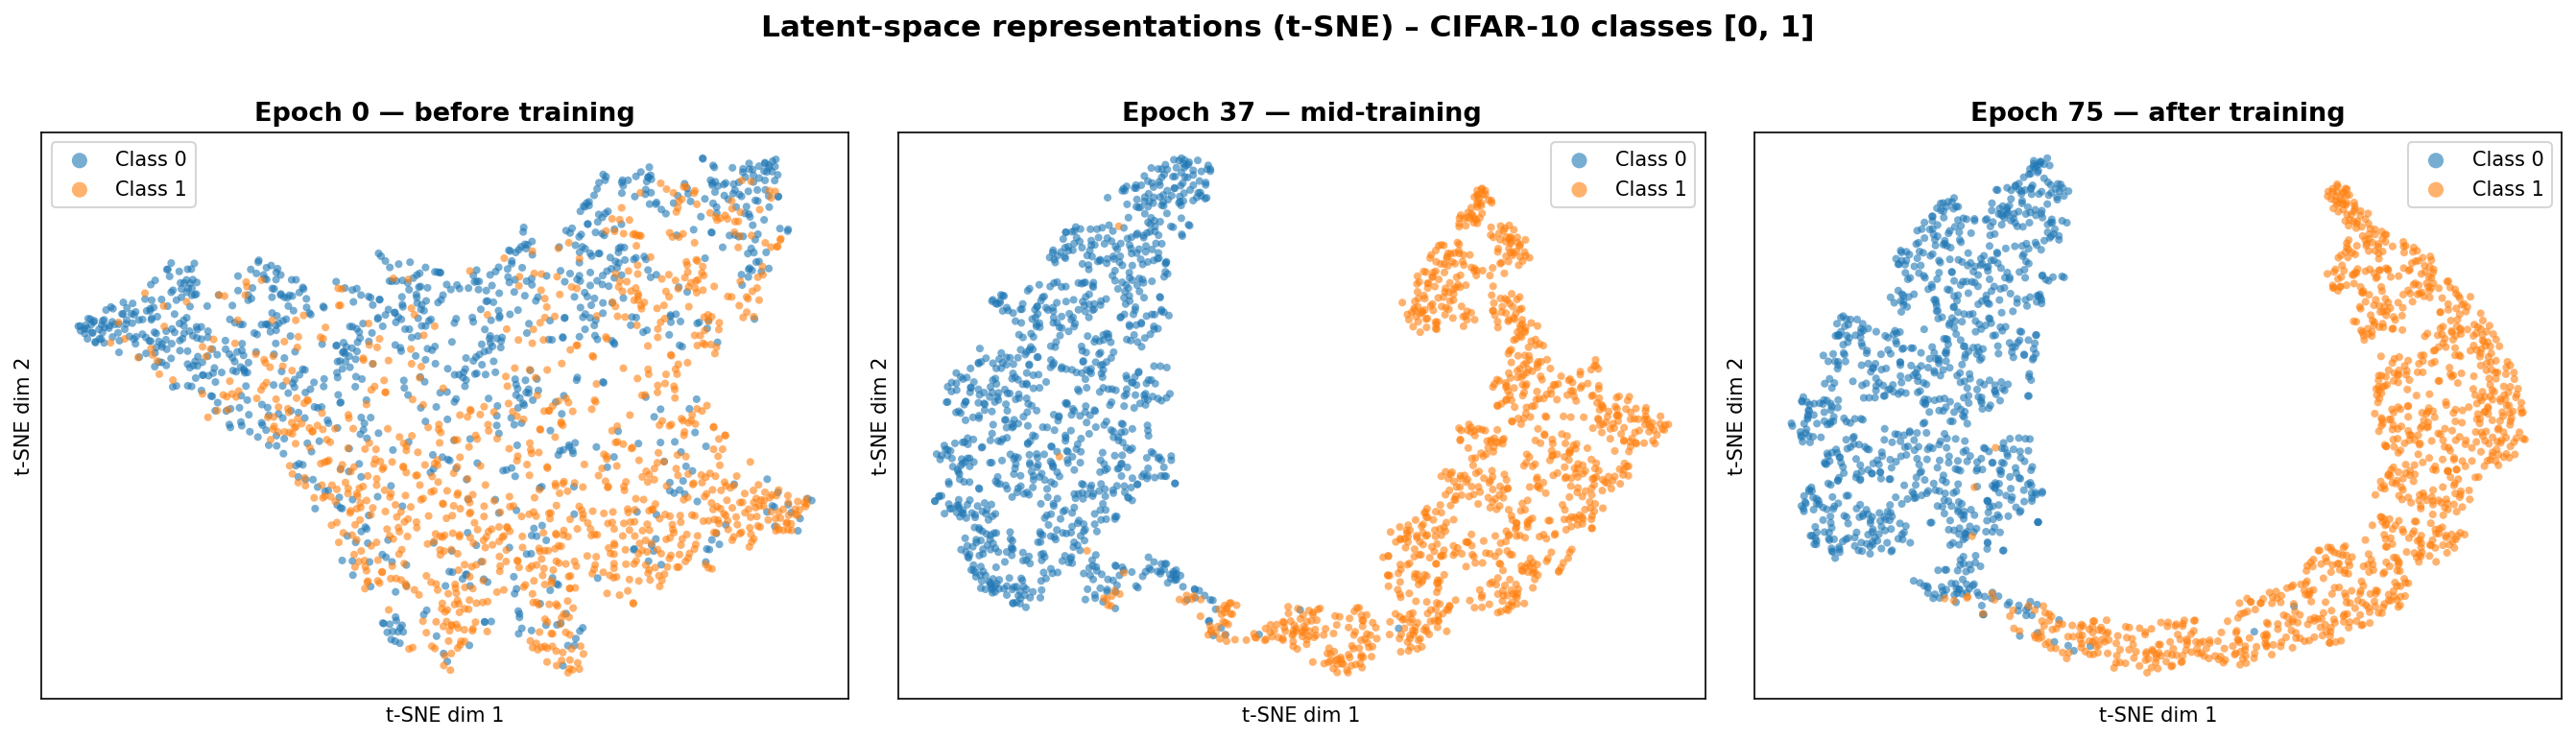

In [6]:
snap_path = os.path.join(GRAPHS_DIR, 'latent_space_snapshots.png')
if os.path.exists(snap_path):
    from IPython.display import Image, display
    display(Image(snap_path))
else:
    print('Run backbone training first to generate snapshots.')

---
## 3 · Continual Learning methods (Etapa 4.3)

Each method trains sequentially over all 5 tasks and records Class-IL and Task-IL accuracy after each task.  
Results are cached in `graphs/results.json` — re-run only the methods you change.

In [7]:
# Load existing results (if any) so we don't re-run completed methods
if os.path.exists(RESULTS_PATH):
    with open(RESULTS_PATH) as f:
        results = json.load(f)
    print(f'Loaded cached results for: {list(results.keys())}')
else:
    results = {}
    print('No cached results — will run all selected methods.')

def _save_results():
    with open(RESULTS_PATH, 'w') as f:
        json.dump(results, f, indent=2)
    print(f'Saved → {RESULTS_PATH}')

Loaded cached results for: ['Fine-Tune', 'EWC', 'LwF']


### 3.1 · Fine-Tune (naive baseline)

In [8]:
if RUN_FINETUNE:
    print('Running Fine-Tune …')
    results['Fine-Tune'] = train_finetune(
        backbone_weights=BACKBONE_WEIGHTS,
        num_epochs=CL_EPOCHS, lr=CL_LR, batch_size=BATCH_SIZE,
        head_epochs=HEAD_EPOCHS, head_lr=HEAD_LR,
    )
    _save_results()
else:
    print('Fine-Tune skipped (RUN_FINETUNE=False)')

Running Fine-Tune …

Fine-Tune  |  Task 1 / 5
  Epoch [1/10]  Loss: 0.0176
  Epoch [2/10]  Loss: 0.0033
  Epoch [3/10]  Loss: 0.0019
  Epoch [4/10]  Loss: 0.0023
  Epoch [5/10]  Loss: 0.0017
  Epoch [6/10]  Loss: 0.0019
  Epoch [7/10]  Loss: 0.0011
  Epoch [8/10]  Loss: 0.0007
  Epoch [9/10]  Loss: 0.0007
  Epoch [10/10]  Loss: 0.0004
  Training Task-IL head for task 1…
  >> Class-IL: 98.90%  |  Task-IL: 98.80%

Fine-Tune  |  Task 2 / 5
  Epoch [1/10]  Loss: 0.8713
  Epoch [2/10]  Loss: 0.5004
  Epoch [3/10]  Loss: 0.4146
  Epoch [4/10]  Loss: 0.3608
  Epoch [5/10]  Loss: 0.3356
  Epoch [6/10]  Loss: 0.3116
  Epoch [7/10]  Loss: 0.3025
  Epoch [8/10]  Loss: 0.2733
  Epoch [9/10]  Loss: 0.2591
  Epoch [10/10]  Loss: 0.2514
  Training Task-IL head for task 2…
  >> Class-IL: 44.02%  |  Task-IL: 87.88%

Fine-Tune  |  Task 3 / 5
  Epoch [1/10]  Loss: 0.7604
  Epoch [2/10]  Loss: 0.2771
  Epoch [3/10]  Loss: 0.2373
  Epoch [4/10]  Loss: 0.2114
  Epoch [5/10]  Loss: 0.1973
  Epoch [6/10]  Los

### 3.2 · Elastic Weight Consolidation (EWC)

In [9]:
if RUN_EWC:
    print('Running EWC …')
    results['EWC'] = train_ewc(
        backbone_weights=BACKBONE_WEIGHTS,
        lambda_ewc=LAMBDA_EWC, fisher_samples=FISHER_SAMPLES,
        num_epochs=CL_EPOCHS, lr=CL_LR, batch_size=BATCH_SIZE,
        head_epochs=HEAD_EPOCHS, head_lr=HEAD_LR,
    )
    _save_results()
else:
    print('EWC skipped (RUN_EWC=False)')

Running EWC …

EWC  |  Task 1 / 5
  Epoch [1/10]  Loss: 0.0260
  Epoch [2/10]  Loss: 0.0045
  Epoch [3/10]  Loss: 0.0023
  Epoch [4/10]  Loss: 0.0019
  Epoch [5/10]  Loss: 0.0029
  Epoch [6/10]  Loss: 0.0024
  Epoch [7/10]  Loss: 0.0021
  Epoch [8/10]  Loss: 0.0022
  Epoch [9/10]  Loss: 0.0024
  Epoch [10/10]  Loss: 0.0012
  Computing Fisher Information Matrix…
  >> Class-IL: 99.10%  |  Task-IL: 99.10%

EWC  |  Task 2 / 5
  Epoch [1/10]  Loss: 0.7748
  Epoch [2/10]  Loss: 0.4830
  Epoch [3/10]  Loss: 0.4003
  Epoch [4/10]  Loss: 0.3628
  Epoch [5/10]  Loss: 0.3222
  Epoch [6/10]  Loss: 0.2980
  Epoch [7/10]  Loss: 0.2834
  Epoch [8/10]  Loss: 0.2696
  Epoch [9/10]  Loss: 0.2534
  Epoch [10/10]  Loss: 0.2419
  Computing Fisher Information Matrix…
  >> Class-IL: 44.35%  |  Task-IL: 90.30%

EWC  |  Task 3 / 5
  Epoch [1/10]  Loss: 0.7422
  Epoch [2/10]  Loss: 0.2930
  Epoch [3/10]  Loss: 0.2605
  Epoch [4/10]  Loss: 0.2327
  Epoch [5/10]  Loss: 0.2170
  Epoch [6/10]  Loss: 0.2050
  Epoch 

### 3.3 · Learning without Forgetting (LwF)

In [10]:
if RUN_LWF:
    print('Running LwF …')
    results['LwF'] = train_lwf(
        backbone_weights=BACKBONE_WEIGHTS,
        lambda_lwf=LAMBDA_LWF, temperature=TEMPERATURE_LWF,
        num_epochs=CL_EPOCHS, lr=CL_LR, batch_size=BATCH_SIZE,
        head_epochs=HEAD_EPOCHS, head_lr=HEAD_LR,
    )
    _save_results()
else:
    print('LwF skipped (RUN_LWF=False)')

Running LwF …

LwF  |  Task 1 / 5
  Epoch [1/10]  Loss: 0.0157
  Epoch [2/10]  Loss: 0.0042
  Epoch [3/10]  Loss: 0.0025
  Epoch [4/10]  Loss: 0.0015
  Epoch [5/10]  Loss: 0.0017
  Epoch [6/10]  Loss: 0.0025
  Epoch [7/10]  Loss: 0.0008
  Epoch [8/10]  Loss: 0.0009
  Epoch [9/10]  Loss: 0.0020
  Epoch [10/10]  Loss: 0.0006
  >> Class-IL: 99.00%  |  Task-IL: 99.05%

LwF  |  Task 2 / 5
  Epoch [1/10]  Loss: 1.7410
  Epoch [2/10]  Loss: 0.6913
  Epoch [3/10]  Loss: 0.6071
  Epoch [4/10]  Loss: 0.5563
  Epoch [5/10]  Loss: 0.5082
  Epoch [6/10]  Loss: 0.4613
  Epoch [7/10]  Loss: 0.4317
  Epoch [8/10]  Loss: 0.4208
  Epoch [9/10]  Loss: 0.3900
  Epoch [10/10]  Loss: 0.3830
  >> Class-IL: 42.62%  |  Task-IL: 91.35%

LwF  |  Task 3 / 5
  Epoch [1/10]  Loss: 0.9597
  Epoch [2/10]  Loss: 0.3597
  Epoch [3/10]  Loss: 0.3295
  Epoch [4/10]  Loss: 0.3026
  Epoch [5/10]  Loss: 0.2850
  Epoch [6/10]  Loss: 0.2693
  Epoch [7/10]  Loss: 0.2551
  Epoch [8/10]  Loss: 0.2531
  Epoch [9/10]  Loss: 0.2429

### 3.4 · Contrastive Continual Learning (Co²L)

In [11]:
if RUN_CO2L:
    print('Running Co²L …')
    results['Co2L'] = train_co2l(
        backbone_weights=BACKBONE_WEIGHTS,
        lambda_co2l=LAMBDA_CO2L, temperature=TEMPERATURE,
        buffer_size=BUFFER_SIZE,
        num_epochs=CL_EPOCHS, lr=CL_LR, batch_size=BATCH_SIZE,
        head_epochs=HEAD_EPOCHS, head_lr=HEAD_LR,
    )
    _save_results()
else:
    print('Co²L skipped (RUN_CO2L=False)')

Running Co²L …

Co2L  |  Task 1 / 5
  Epoch [1/10]  Loss: 3.4419  SupCon: 3.4419  IRD: 0.0000
  Epoch [2/10]  Loss: 3.4386  SupCon: 3.4386  IRD: 0.0000
  Epoch [3/10]  Loss: 3.4388  SupCon: 3.4388  IRD: 0.0000
  Epoch [4/10]  Loss: 3.4364  SupCon: 3.4364  IRD: 0.0000
  Epoch [5/10]  Loss: 3.4369  SupCon: 3.4369  IRD: 0.0000
  Epoch [6/10]  Loss: 3.4349  SupCon: 3.4349  IRD: 0.0000
  Epoch [7/10]  Loss: 3.4345  SupCon: 3.4345  IRD: 0.0000
  Epoch [8/10]  Loss: 3.4354  SupCon: 3.4354  IRD: 0.0000
  Epoch [9/10]  Loss: 3.4388  SupCon: 3.4388  IRD: 0.0000
  Epoch [10/10]  Loss: 3.4384  SupCon: 3.4384  IRD: 0.0000
  Updating replay buffer (capacity=200)…
  ReplayBuffer(capacity=200, stored=200, seen=10000)
  Training Class-IL joint head…
  >> Class-IL: 99.15%  |  Task-IL: 99.10%

Co2L  |  Task 2 / 5
  Epoch [1/10]  Loss: nan  SupCon: 4.7574  IRD: nan
  Epoch [2/10]  Loss: nan  SupCon: 4.6130  IRD: nan
  Epoch [3/10]  Loss: nan  SupCon: 4.5165  IRD: nan
  Epoch [4/10]  Loss: nan  SupCon: 4.4

---
## 4 · Comparison of results (Etapa 4.4)

### 4.1 · Unified results table

In [12]:
METHODS = ['Fine-Tune', 'EWC', 'LwF', 'Co2L']
COLORS  = ['tab:red', 'tab:orange', 'tab:blue', 'tab:green']
TASK_LABELS = [f'T{i}' for i in range(1, 6)]

col_w = 12
header = f'{"Method":<{col_w}}' + ''.join(
    f'  {"T"+str(t)+" CIL":>8}  {"T"+str(t)+" TIL":>8}' for t in range(1, 6)
)
sep = '=' * len(header)
print(sep)
print('RESULTS — Class-IL (CIL) and Task-IL (TIL) accuracy (%) after each task')
print(sep)
print(header)
print('-' * len(header))
for method in METHODS:
    if method not in results:
        continue
    r = results[method]
    row = f'{method:<{col_w}}'
    for i in range(5):
        row += f'  {r["class_il"][i]:>8.2f}  {r["task_il"][i]:>8.2f}'
    print(row)
print(sep)

RESULTS — Class-IL (CIL) and Task-IL (TIL) accuracy (%) after each task
Method          T1 CIL    T1 TIL    T2 CIL    T2 TIL    T3 CIL    T3 TIL    T4 CIL    T4 TIL    T5 CIL    T5 TIL
----------------------------------------------------------------------------------------------------------------
Fine-Tune        98.90     98.80     44.02     87.88     30.82     82.73     24.52     69.97     19.27     61.81
EWC              99.10     99.10     44.35     90.30     31.03     84.93     24.40     73.69     19.31     76.33
LwF              99.00     99.05     42.62     91.35     30.93     92.23     24.36     90.95     19.27     86.61
Co2L             99.15     99.10     63.05     88.07     43.42     84.77     32.79     79.40     21.16     82.84


### 4.2 · Accuracy curves

In [13]:
tasks = list(range(1, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Continual Learning on Seq-CIFAR-10', fontsize=14, fontweight='bold')

for method, color in zip(METHODS, COLORS):
    if method not in results:
        continue
    r = results[method]
    ax1.plot(tasks, r['class_il'], marker='o', label=method, color=color, linewidth=2)
    ax2.plot(tasks, r['task_il'],  marker='o', label=method, color=color, linewidth=2)

for ax, title in [
    (ax1, 'Class-Incremental Learning (Class-IL)'),
    (ax2, 'Task-Incremental Learning (Task-IL)'),
]:
    ax.set_xlabel('Tasks Learned', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_xticks(tasks)
    ax.set_xticklabels(TASK_LABELS)
    ax.set_ylim(0, 100)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(GRAPHS_DIR, 'accuracy_curves.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

Saved → graphs/accuracy_curves.png


/tmp/ipykernel_562038/4059640810.py:28: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 4.3 · Forgetting curves

Class-IL accuracy over tasks acts as a forgetting proxy: a steeper drop means more catastrophic forgetting.

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.set_title(
    'Forgetting — Class-IL Accuracy Over Tasks\n'
    '(steeper drop = more catastrophic forgetting)',
    fontsize=12,
)
for method, color in zip(METHODS, COLORS):
    if method not in results:
        continue
    r = results[method]
    ax.plot(tasks, r['class_il'], marker='o', label=method, color=color, linewidth=2)

ax.set_xlabel('Tasks Learned', fontsize=11)
ax.set_ylabel('Class-IL Accuracy (%)', fontsize=11)
ax.set_xticks(tasks)
ax.set_xticklabels(TASK_LABELS)
ax.set_ylim(0, 100)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(GRAPHS_DIR, 'forgetting_curves.png')
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {path}')

Saved → graphs/forgetting_curves.png


/tmp/ipykernel_562038/960760234.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### 4.4 · Final accuracy summary (after all 5 tasks)

In [15]:
print(f'{"Method":<12}  {"Final Class-IL":>15}  {"Final Task-IL":>14}')
print('-' * 46)
for method in METHODS:
    if method not in results:
        continue
    r = results[method]
    print(f'{method:<12}  {r["class_il"][-1]:>14.2f}%  {r["task_il"][-1]:>13.2f}%')

print('\nPaper targets (Co²L on Seq-CIFAR-10):')
print('  Class-IL ≈ 47–52%   Task-IL ≈ 88–92%')

Method         Final Class-IL   Final Task-IL
----------------------------------------------
Fine-Tune              19.27%          61.81%
EWC                    19.31%          76.33%
LwF                    19.27%          86.61%
Co2L                   21.16%          82.84%

Paper targets (Co²L on Seq-CIFAR-10):
  Class-IL ≈ 47–52%   Task-IL ≈ 88–92%
